In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'lines.linewidth': 2})

# EH Self Acceleration In Sine Electric Field

In [3]:
L = 60 * np.pi
nx = 4000
dx = L / (nx - 1)

vmax_e = 10  # 速度最大值
nv_e = 2000
dv_e = 2 * vmax_e / (nv_e - 1)

vmax_i = 0.52185  # 速度最大值
nv_i = 2000
dv_i = 2 * vmax_i / (nv_i - 1)

x = np.linspace(0, L, num=nx, endpoint=True)
ve = np.linspace(-vmax_e, vmax_e, num=nv_e, endpoint=True)
vi = np.linspace(-vmax_i, vmax_i, num=nv_i, endpoint=True)
Ve, Xe = np.meshgrid(ve, x)
Vi, Xi = np.meshgrid(vi, x)

Ea_s = 5
Ea_e = 505

dt = 0.05
max_steps = 30000
data_steps = int(max_steps / 5)
data_num = int(max_steps / data_steps) + 1

path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03"

print(data_num)
print("real time = ", max_steps * dt)

6
real time =  1500.0


In [4]:
phi = np.loadtxt(os.path.join(path, "Phi_evolution"))
t = np.linspace(0, max_steps, num = max_steps + 1, endpoint=True) * dt

In [5]:
progesses = np.arange(0,data_num,1)

fe = []
fi = []

for progess in tqdm(progesses):
    fe_temp = np.loadtxt(os.path.join(path,"fe"+str(progess)))
    fe.append(fe_temp)
    fi_temp = np.loadtxt(os.path.join(path,"fi"+str(progess)))
    fi.append(fi_temp)

100%|██████████| 6/6 [00:08<00:00,  1.39s/it]


In [6]:
ne = np.sum(fe,axis=2)*dv_e
lve = np.linspace(fe[0].min(),fe[0].max(),num=25)
ni = np.sum(fi,axis=2)*dv_i
lvi = np.linspace(fi[0].min(),fi[0].max(),num=15)

C:\Users\RGuo\AppData\Local\Temp\ipykernel_18428\1597954099.py:9: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000024E172036D0>' will be ignored
  ax1cm.set_rasterized(True)
C:\Users\RGuo\AppData\Local\Temp\ipykernel_18428\1597954099.py:15: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000024E17237ED0>' will be ignored
  ax2cm.set_rasterized(True)


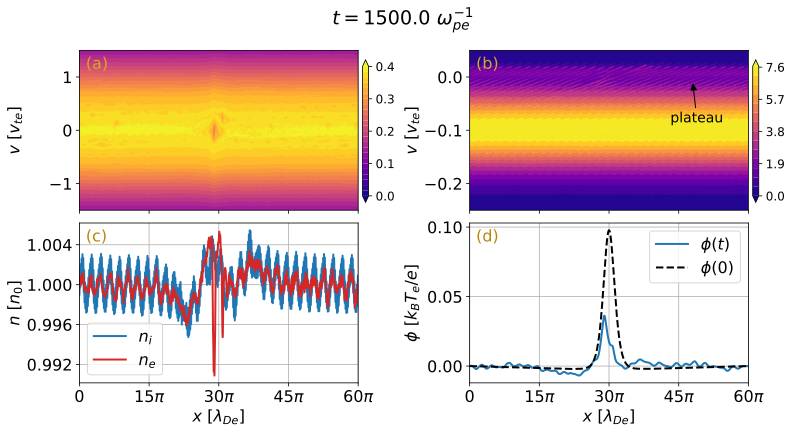

In [ ]:
x_ticks = [0, 15 * np.pi, 30 * np.pi, 45 * np.pi, 60 * np.pi]

test_frame = data_num - 1
fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(
    figsize=(12, 6), ncols=2, nrows=2, sharex=True
)
ax1 = plt.subplot(221)
ax1cm = ax1.contourf(Xe, Ve, fe[test_frame], levels=lve, extend="both", cmap=cm.plasma)
ax1cm.set_rasterized(True)
ax1.set_ylabel(r"$v~[v_{te}]$")
ax1.set_ylim(-1.5, 1.5)

ax2 = plt.subplot(222)
ax2cm = ax2.contourf(Xi, Vi, fi[test_frame], levels=lvi, extend="both", cmap=cm.plasma)
ax2cm.set_rasterized(True)
ax2.set_ylabel(r"$v~[v_{te}]$")
ax2.set_ylim(-0.25, 0.05)

ax3 = plt.subplot(223)
ax3.plot(x, ni[test_frame], color="tab:blue", label="$n_i$")
ax3.plot(x, ne[test_frame], color="tab:red", label="$n_e$")
ax3.set_ylabel(r"$n~[n_0]$")
ax3.set_xlabel(r"$x~[\lambda_{De}]$")
ax3.set_xticks(x_ticks, labels=[r"$0$", r"$15\pi$", r"$30\pi$", r"$45\pi$", r"$60\pi$"])
ax3.set_yticks([0.992, 0.996, 1.000, 1.004])
ax3.legend()
ax3.grid()

ax4 = plt.subplot(224)
ax4.plot(x, phi[:, -1], color="tab:blue", label=r"$\phi(t)$")
ax4.plot(x, phi[:, 0], "--", color="black", label=r"$\phi(0)$")
ax4.set_xlabel(r"$x~[\lambda_{De}]$")
ax4.set_ylabel(r"$\phi~[k_B T_e/e]$")
ax4.set_xticks(x_ticks, labels=[r"$0$", r"$15\pi$", r"$30\pi$", r"$45\pi$", r"$60\pi$"])
ax4.legend()
ax4.grid()

cax1 = fig.add_axes([0.453, 0.528, 0.007, 0.33])
cbar1 = fig.colorbar(
    ax1cm,
    cax=cax1,
    orientation="vertical",
    shrink=1.0,
    ticks=[0.0, 0.1, 0.2, 0.3, 0.4],
    extend="both",
)
cbar1.ax.tick_params(labelsize=12)

cax2 = fig.add_axes([0.905, 0.528, 0.007, 0.33])
cbar2 = fig.colorbar(
    ax2cm,
    cax=cax2,
    orientation="vertical",
    shrink=1.0,
    ticks=[0.0, 1.9, 3.8, 5.7, 7.6],
    extend="both",
)
cbar2.ax.tick_params(labelsize=12)

ax2.annotate(
    r"plateau",
    xy=(0.8, 0.807),
    xytext=(0.72, 0.55),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", facecolor="black"),
    fontsize=14,
    # color="goldenrod",
)

ax1.text(0.023, 0.885, "(a)", transform=ax1.transAxes, color="goldenrod")
ax2.text(0.023, 0.885, "(b)", transform=ax2.transAxes, color="goldenrod")
ax3.text(0.023, 0.885, "(c)", transform=ax3.transAxes, color="darkgoldenrod")
ax4.text(0.023, 0.885, "(d)", transform=ax4.transAxes, color="darkgoldenrod")

fig.subplots_adjust(wspace=0.4, hspace=0.08)
fig.align_ylabels()

plt.suptitle(r"$t=$" + str(test_frame * data_steps * dt) + r"$~\omega_{pe}^{-1}$")

# plt.savefig("./fig9_phase_space_final_sinE03.pdf", bbox_inches='tight', dpi = 600)
plt.show()

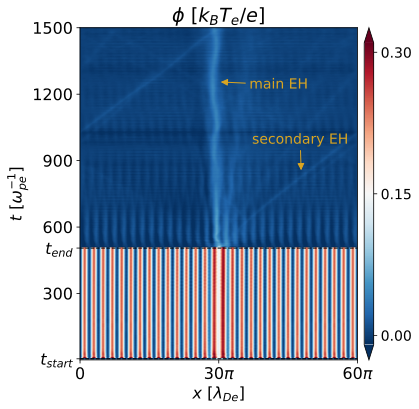

In [ ]:
T, X = np.meshgrid(t, x)

fig = plt.figure(figsize=(6, 6))
cb = plt.pcolormesh(X, T, phi, vmin=-0.01, vmax=0.31, cmap=cm.RdBu_r, rasterized=True)

plt.axhline(y=Ea_s, color="black", linestyle="--", linewidth=1)
plt.axhline(y=Ea_e, color="black", linestyle="--", linewidth=1)

plt.ylabel(r"$t~[\omega_{pe}^{-1}]$")
plt.xlabel(r"$x~[\lambda_{De}]$")
plt.xticks([0, 30 * np.pi, 60 * np.pi], ["0", r"$30\pi$", r"$60\pi$"])
plt.yticks(
    [Ea_s, 300, Ea_e, 600, 900, 1200, 1500],
    [r"$t_{start}$", r"$300$", r"$t_{end}$", r"$600$", r"$900$", r"$1200$", r"$1500$"],
)

plt.annotate(
    r"main EH",
    xy=(0.5, 0.837),
    xytext=(0.61, 0.817),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", facecolor="goldenrod", edgecolor="goldenrod"),
    fontsize=14,
    color="goldenrod",
)

plt.annotate(
    r"secondary EH",
    xy=(0.797, 0.565),
    xytext=(0.62, 0.651),
    xycoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", facecolor="goldenrod", edgecolor="goldenrod"),
    fontsize=14,
    color="goldenrod",
)

cbar = plt.colorbar(cb, ticks=[0.0, 0.15, 0.30], extend="both", aspect=35, pad=0.02)
cbar.ax.tick_params(labelsize=14)
plt.title(r"$\phi~[k_B T_e/e]$")
# plt.savefig("./fig8_phi_evo_sinE03.pdf", bbox_inches='tight', dpi = 600)55
plt.show()

In [9]:
phi_final = phi[:,-1]
x_peak_idx = np.argmax(phi_final)
x_peak = x_peak_idx * dx
print("x_peak = ", x_peak)

x_peak =  91.11325730516234


psi =  0.03235025669536895 Delta =  3.8274332317185285


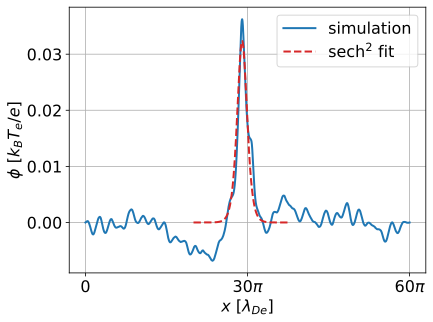

In [10]:
def phi2_theo(x, psi_fit, delta_fit):
    xp = (x - x_peak) / delta_fit
    return psi_fit * np.cosh(xp) ** (-2)


fit_offset = 600
x_fit_scale = x[x_peak_idx - fit_offset : x_peak_idx + fit_offset]
phi_fit = phi_final[x_peak_idx - fit_offset : x_peak_idx + fit_offset]
[psi_fit, Delta_fit], pcov = curve_fit(phi2_theo, x_fit_scale, phi_fit)

print("psi = ", psi_fit, "Delta = ", Delta_fit)
plt.plot(x, phi_final, color="tab:blue", label=r"simulation")
plt.plot(
    x_fit_scale,
    phi2_theo(x_fit_scale, psi_fit, Delta_fit),
    "--",
    color="tab:red",
    label=r"$\mathrm{sech}^2$ fit",
)
plt.xlabel(r"$x~[\lambda_{De}]$")
plt.ylabel(r"$\phi~[k_BT_e/e]$")
plt.xticks([0, 30 * np.pi, 60 * np.pi], ["0", r"$30\pi$", r"$60\pi$"])
plt.legend()
plt.grid()
plt.show()

In [11]:
ui = 0.1
Ti = 5
mi = 1836
vti = np.sqrt(Ti/mi)
E_amp = 0.3
vi_r = np.sqrt(2*psi_fit/mi) 
ve_E = np.sqrt(2*E_amp)       # k=1
vi_E = np.sqrt(2*E_amp/mi)
print("vi_r:", vi_r)
print("ve_E:", ve_E)
print("vi_E:", vi_E)

vi_r: 0.005936323023615454
ve_E: 0.7745966692414834
vi_E: 0.01807753815155468


In [12]:
fe_sim_smooth = savgol_filter(fe[test_frame][0,:], window_length=80, polyorder=7)
fi_sim_smooth = savgol_filter(fi[test_frame][0,:], window_length=80, polyorder=7)

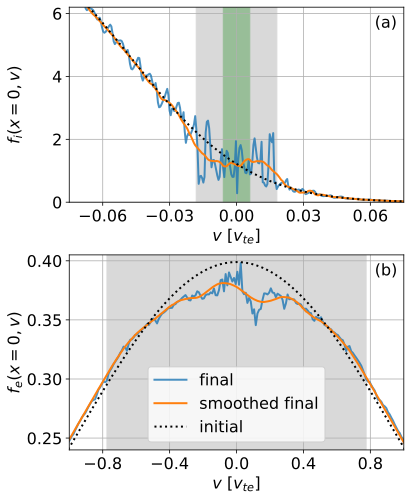

In [ ]:
xe_ticks = [-0.8, -0.4, 0.0, 0.4, 0.8]
xi_ticks = [-0.06, -0.03, 0.0, 0.03, 0.06]
fig, (ax1, ax2) = plt.subplots(
    figsize=(6, 8), nrows=2, ncols=1, sharex=False, sharey=False
)

ax1.plot(
    vi, fi[test_frame][0, :], linestyle="-", color="tab:blue", alpha=0.8, label="final"
)
ax1.plot(vi, fi_sim_smooth, linestyle="-", color="tab:orange", label="smoothed final")
ax1.plot(vi, fi[0][0, :], linestyle=":", color="black", label="initial")
ax1.axvspan(-vi_E, vi_E, alpha=0.3, color="gray")
ax1.axvspan(-vi_r, vi_r, alpha=0.3, color="green")

ax1.set_xlim(-0.075, +0.075)
ax1.set_xlabel(r"$v ~[v_{te}]$")
ax1.set_ylabel(r"$f_i(x=0, v)$")
ax1.set_ylim(0, 6.2)
ax1.set_xticks(xi_ticks)
ax1.grid()

ax2.plot(
    ve, fe[test_frame][0, :], linestyle="-", color="tab:blue", alpha=0.8, label="final"
)
ax2.plot(ve, fe_sim_smooth, linestyle="-", color="tab:orange", label="smoothed final")
ax2.plot(ve, fe[0][0, :], linestyle=":", color="black", label="initial")
ax2.axvspan(-ve_E, ve_E, alpha=0.3, color="gray")

ax2.set_xlim(-1.0, +1.0)
ax2.set_ylim(0.24, 0.405)
ax2.set_xlabel(r"$v ~[v_{te}]$")
ax2.set_ylabel(r"$f_e(x=0, v)$")
ax2.set_xticks(xe_ticks)
ax2.grid()
ax2.legend()


ax1.text(0.913, 0.895, "(a)", transform=ax1.transAxes)
ax2.text(0.913, 0.895, "(b)", transform=ax2.transAxes)

fig.subplots_adjust(hspace=0.27)
fig.align_ylabels()
# plt.savefig("./fig10_pdf_final_sinE03.pdf", bbox_inches='tight', dpi = 600)
plt.show()